In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne


# ============================================================
# 1. Load existing feature tables
# ============================================================

BASE = r"H:\ASD projoect"

ASD = pd.read_csv(
    rf"{BASE}\ASD_Pearson_features.csv"
)

TD = pd.read_csv(
    rf"{BASE}\TD_Pearson_features.csv"
)

print("ASD:", len(ASD))
print("TD:", len(TD))


# ============================================================
# 2. Bands and ROIs
# ============================================================

BANDS = [
    "theta",
    "alpha",
    "low_beta",
    "beta"
]

ROIS = [
    "frontal",
    "frontocentral",
    "central",
    "centroparietal",
    "parietal",
    "posterior"
]


ROI_CHANNELS = {
    "frontal": [
        "Fp1", "Fpz", "Fp2",
        "AF3", "AF4",
        "F7", "F5", "F3", "F1",
        "Fz", "F2", "F4", "F6", "F8"
    ],

    "frontocentral": [
        "FT7", "FC5", "FC3", "FC1",
        "FCz", "FC2", "FC4", "FC6", "FT8"
    ],

    "central": [
        "T7", "C5", "C3", "C1",
        "Cz", "C2", "C4", "C6", "T8"
    ],

    "centroparietal": [
        "TP7", "CP5", "CP3", "CP1",
        "CPz", "CP2", "CP4", "CP6", "TP8"
    ],

    "parietal": [
        "P7", "P5", "P3", "P1",
        "Pz", "P2", "P4", "P6", "P8"
    ],

    "posterior": [
        "PO7", "PO5", "PO3", "POz",
        "PO4", "PO6", "PO8",
        "O1", "Oz", "O2"
    ]
}

ASD: 33
TD: 29


In [3]:
# ============================================================
# 3. MNE topomap setup
# ============================================================

CHANNELS = []

for roi in ROIS:
    CHANNELS.extend(
        ROI_CHANNELS[roi]
    )


info = mne.create_info(
    ch_names=CHANNELS,
    sfreq=200,
    ch_types="eeg"
)

montage = mne.channels.make_standard_montage(
    "standard_1020"
)

info.set_montage(
    montage,
    match_case=False,
    on_missing="ignore"
)


def roi_to_channels(roi_values):
    """
    roi_values:
        dict like
        {'frontal': ..., 'frontocentral': ..., ...}
    """

    values = []

    for roi in ROIS:

        values.extend(
            [roi_values[roi]]
            * len(ROI_CHANNELS[roi])
        )

    return np.array(values)

In [4]:
# ============================================================
# 4. EF: Nogo - Go
# ============================================================

def get_ef_difference(df):

    results = {}

    for band in BANDS:

        results[band] = {}

        for roi in ROIS:

            nogo_col = (
                f"EF_nogo_{band}_{roi}_PSD_dB"
            )

            go_col = (
                f"EF_go_{band}_{roi}_PSD_dB"
            )

            # participant-level contrast first
            diff = (
                df[nogo_col]
                - df[go_col]
            )

            # then group mean
            results[band][roi] = (
                diff.mean()
            )

    return results


EF_ASD = get_ef_difference(ASD)
EF_TD  = get_ef_difference(TD)

In [5]:
# ============================================================
# 5. ToM: False - True
# ============================================================

def get_tom_difference(
    df,
    segment,
    domain
):

    results = {}

    for band in BANDS:

        results[band] = {}

        for roi in ROIS:

            false_col = (
                f"{segment}_false_{domain}_"
                f"{band}_{roi}_PSD_dB"
            )

            true_col = (
                f"{segment}_true_{domain}_"
                f"{band}_{roi}_PSD_dB"
            )

            diff = (
                df[false_col]
                - df[true_col]
            )

            results[band][roi] = (
                diff.mean()
            )

    return results

In [6]:
# ============================================================
# 6. Plot ASD and TD together
# ============================================================

def plot_psd_topomaps(
    asd_result,
    td_result,
    title
):

    ASD_maps = {
        band:
        roi_to_channels(
            asd_result[band]
        )
        for band in BANDS
    }

    TD_maps = {
        band:
        roi_to_channels(
            td_result[band]
        )
        for band in BANDS
    }


    # same scale for ASD and TD
    all_values = np.concatenate(
        [
            ASD_maps[b]
            for b in BANDS
        ]
        +
        [
            TD_maps[b]
            for b in BANDS
        ]
    )

    vmax = np.nanmax(
        np.abs(all_values)
    )


    fig, axes = plt.subplots(
        2,
        4,
        figsize=(13, 6)
    )

    fig.suptitle(
        title,
        fontsize=15
    )


    for j, band in enumerate(BANDS):

        im, _ = mne.viz.plot_topomap(
            ASD_maps[band],
            info,
            axes=axes[0, j],
            show=False,
            cmap="RdBu_r",
            vlim=(-vmax, vmax),
            contours=6
        )

        axes[0, j].set_title(
            band.replace("_", "-")
        )


        mne.viz.plot_topomap(
            TD_maps[band],
            info,
            axes=axes[1, j],
            show=False,
            cmap="RdBu_r",
            vlim=(-vmax, vmax),
            contours=6
        )


    # row labels
    axes[0, 0].text(
        -0.35,
        0.5,
        "ASD",
        transform=axes[0, 0].transAxes,
        fontsize=13,
        fontweight="bold",
        rotation=90,
        va="center"
    )

    axes[1, 0].text(
        -0.35,
        0.5,
        "TD",
        transform=axes[1, 0].transAxes,
        fontsize=13,
        fontweight="bold",
        rotation=90,
        va="center"
    )


    fig.colorbar(
        im,
        ax=axes,
        shrink=0.75,
        label="PSD difference (dB)"
    )

    plt.show()

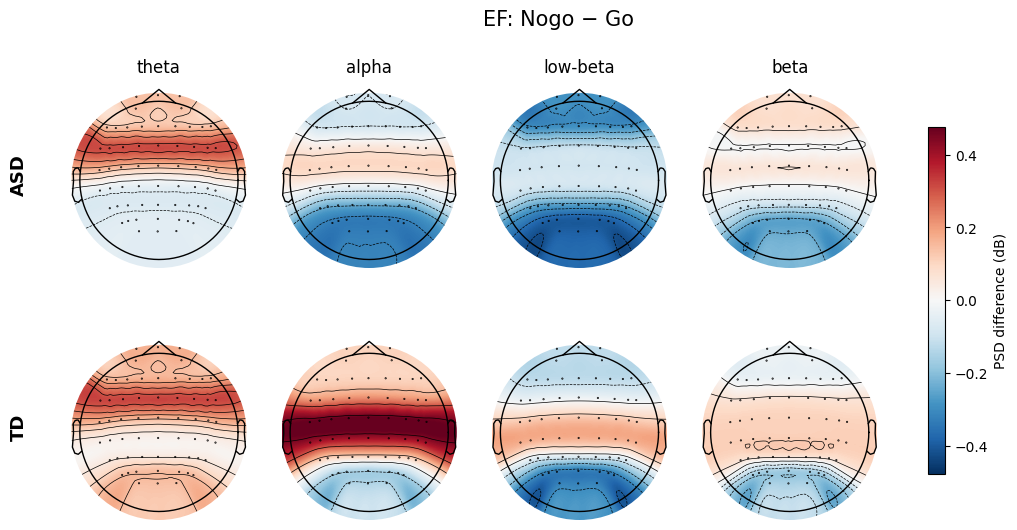

In [7]:
plot_psd_topomaps(
    EF_ASD,
    EF_TD,
    "EF: Nogo − Go"
)

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
import mne

In [9]:
BASE = Path(r"H:\ASD projoect")

EF_ROOTS = {
    "ASD": BASE / "EF" / "ASD",
    "TD":  BASE / "EF" / "TD",
}

TOM_ROOTS = {
    "ASD": BASE / "ToM" / "ASD",
    "TD":  BASE / "ToM" / "TD",
}

In [10]:
BANDS = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "low_beta": (13, 20),
    "beta": (20, 30),
}

In [11]:
def find_ef_files(group):
    root = EF_ROOTS[group]
    files = []

    for p in root.glob("*_processed_numpy/interpolated_epoch.npy"):
        files.append(p)

    files = sorted(files)
    print(group, "EF files:", len(files))
    return files


def find_tom_files(group, segment="H"):
    root = TOM_ROOTS[group]

    if segment == "H":
        target = "interpolated_hearing_epoch.npy"
    elif segment == "T":
        target = "interpolated_thinking_epoch.npy"
    else:
        raise ValueError("segment must be 'H' or 'T'")

    files = []

    for p in root.glob(f"*_processed_numpy/{target}"):
        files.append(p)

    files = sorted(files)
    print(group, f"ToM-{segment} files:", len(files))
    return files

In [12]:
def load_epoch_npy(file_path):
    data = np.load(file_path, allow_pickle=True).item()

    eeg = np.asarray(data["eeg"], dtype=float)      # epochs x channels x time
    sfreq = float(data["sfreq"])
    ch_names = list(data["channels"])
    metadata = pd.DataFrame(data["metadata"])

    return eeg, sfreq, ch_names, metadata

In [13]:
def standardize_ch_name(ch):
    ch = ch.strip()

    mapping = {
        "FP1": "Fp1",
        "FPZ": "Fpz",
        "FP2": "Fp2",
        "FZ": "Fz",
        "FCZ": "FCz",
        "CZ": "Cz",
        "CPZ": "CPz",
        "PZ": "Pz",
        "POZ": "POz",
        "OZ": "Oz",
    }

    return mapping.get(ch, ch)

In [14]:
def clean_channel_set(eeg, ch_names):
    bad_names = {"HEO", "VEO", "Trigger"}

    keep_idx = [
        i for i, ch in enumerate(ch_names)
        if ch not in bad_names
    ]

    eeg = eeg[:, keep_idx, :]
    ch_names = [standardize_ch_name(ch_names[i]) for i in keep_idx]

    return eeg, ch_names

In [15]:
def compute_band_psd(eeg, sfreq, fmin, fmax):
    """
    eeg: epochs x channels x time
    returns: epochs x channels   (band PSD in dB)
    """
    freqs, psd = welch(
        eeg,
        fs=sfreq,
        nperseg=min(256, eeg.shape[-1]),
        axis=-1
    )

    band_mask = (freqs >= fmin) & (freqs < fmax)

    band_power = psd[:, :, band_mask].mean(axis=-1)
    band_power_db = 10 * np.log10(band_power + 1e-12)

    return band_power_db

In [17]:
def get_ef_masks(metadata):
    cols = metadata.columns.tolist()

    if "condition" in cols:
        cond = metadata["condition"].astype(str).str.lower()
        go_mask = cond == "go"
        nogo_mask = cond == "nogo"
        return go_mask.to_numpy(), nogo_mask.to_numpy()

    if "trial_type" in cols:
        cond = metadata["trial_type"].astype(str).str.lower()
        go_mask = cond == "go"
        nogo_mask = cond == "nogo"
        return go_mask.to_numpy(), nogo_mask.to_numpy()

    trigger_col = None
    for c in ["trigger", "trigger_code", "code", "event_code", "start_code"]:
        if c in cols:
            trigger_col = c
            break

    if trigger_col is None:
        raise RuntimeError("Cannot find EF condition column in metadata")

    trig = pd.to_numeric(metadata[trigger_col], errors="coerce")

    go_mask = trig.isin([11, 12, 13, 14]).to_numpy()
    nogo_mask = trig.isin([51, 52, 53, 54]).to_numpy()

    return go_mask, nogo_mask

In [18]:
def get_tom_masks(metadata, domain="cog"):
    cols = metadata.columns.tolist()

    # Best case: saved labels already exist
    if {"belief", "tom"}.issubset(cols):
        belief = metadata["belief"].astype(str).str.lower()
        tom = metadata["tom"].astype(str).str.lower()

        if domain == "cog":
            false_mask = (belief == "false") & (tom == "cognitive")
            true_mask  = (belief == "true")  & (tom == "cognitive")
        else:
            false_mask = (belief == "false") & (tom == "affective")
            true_mask  = (belief == "true")  & (tom == "affective")

        return false_mask.to_numpy(), true_mask.to_numpy()

    # Alternative: condition column like false_cog / true_aff
    if "condition" in cols:
        cond = metadata["condition"].astype(str).str.lower()

        if domain == "cog":
            false_mask = cond == "false_cog"
            true_mask  = cond == "true_cog"
        else:
            false_mask = cond == "false_aff"
            true_mask  = cond == "true_aff"

        return false_mask.to_numpy(), true_mask.to_numpy()

    # Fallback using start code
    code_col = None
    for c in ["start_code", "trigger", "trigger_code", "code", "event_code"]:
        if c in cols:
            code_col = c
            break

    if code_col is None:
        raise RuntimeError("Cannot find ToM condition column in metadata")

    code = pd.to_numeric(metadata[code_col], errors="coerce")

    if domain == "cog":
        false_mask = code.isin([31, 32]).to_numpy()
        true_mask  = code.isin([131, 132]).to_numpy()
    else:
        false_mask = code.isin([71, 72]).to_numpy()
        true_mask  = code.isin([171, 172]).to_numpy()

    return false_mask, true_mask

In [19]:
def ef_subject_band_effect(file_path):
    eeg, sfreq, ch_names, metadata = load_epoch_npy(file_path)
    eeg, ch_names = clean_channel_set(eeg, ch_names)

    go_mask, nogo_mask = get_ef_masks(metadata)

    if go_mask.sum() == 0 or nogo_mask.sum() == 0:
        raise RuntimeError(f"Missing Go/Nogo trials: {file_path}")

    out = {}

    for band, (fmin, fmax) in BANDS.items():
        band_psd = compute_band_psd(eeg, sfreq, fmin, fmax)

        go_mean = band_psd[go_mask].mean(axis=0)
        nogo_mean = band_psd[nogo_mask].mean(axis=0)

        out[band] = nogo_mean - go_mean   # channel vector

    return out, ch_names

In [20]:
def tom_subject_band_effect(file_path, domain="cog"):
    eeg, sfreq, ch_names, metadata = load_epoch_npy(file_path)
    eeg, ch_names = clean_channel_set(eeg, ch_names)

    false_mask, true_mask = get_tom_masks(metadata, domain=domain)

    if false_mask.sum() == 0 or true_mask.sum() == 0:
        raise RuntimeError(f"Missing False/True trials: {file_path}")

    out = {}

    for band, (fmin, fmax) in BANDS.items():
        band_psd = compute_band_psd(eeg, sfreq, fmin, fmax)

        false_mean = band_psd[false_mask].mean(axis=0)
        true_mean  = band_psd[true_mask].mean(axis=0)

        out[band] = false_mean - true_mean   # channel vector

    return out, ch_names

In [21]:
def ef_group_mean(group):
    files = find_ef_files(group)

    band_maps = {band: [] for band in BANDS}
    ref_ch_names = None
    skipped = []

    for f in files:
        try:
            sub_map, ch_names = ef_subject_band_effect(f)

            if ref_ch_names is None:
                ref_ch_names = ch_names
            else:
                # reorder if necessary
                idx = [ch_names.index(ch) for ch in ref_ch_names]
                for band in BANDS:
                    sub_map[band] = sub_map[band][idx]

            for band in BANDS:
                band_maps[band].append(sub_map[band])

        except Exception as e:
            skipped.append((f.name, str(e)))

    group_mean = {}
    for band in BANDS:
        group_mean[band] = np.mean(np.stack(band_maps[band], axis=0), axis=0)

    print(group, "EF included:", len(files) - len(skipped), "skipped:", len(skipped))
    if skipped:
        print("First few skipped:", skipped[:5])

    return group_mean, ref_ch_names

In [22]:
def tom_group_mean(group, segment="H", domain="cog"):
    files = find_tom_files(group, segment=segment)

    band_maps = {band: [] for band in BANDS}
    ref_ch_names = None
    skipped = []

    for f in files:
        try:
            sub_map, ch_names = tom_subject_band_effect(f, domain=domain)

            if ref_ch_names is None:
                ref_ch_names = ch_names
            else:
                idx = [ch_names.index(ch) for ch in ref_ch_names]
                for band in BANDS:
                    sub_map[band] = sub_map[band][idx]

            for band in BANDS:
                band_maps[band].append(sub_map[band])

        except Exception as e:
            skipped.append((f.name, str(e)))

    group_mean = {}
    for band in BANDS:
        group_mean[band] = np.mean(np.stack(band_maps[band], axis=0), axis=0)

    print(group, f"ToM-{segment}-{domain} included:", len(files) - len(skipped), "skipped:", len(skipped))
    if skipped:
        print("First few skipped:", skipped[:5])

    return group_mean, ref_ch_names

In [23]:
def make_info_from_ch_names(ch_names):
    info = mne.create_info(
        ch_names=ch_names,
        sfreq=200,
        ch_types="eeg"
    )

    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(
        montage,
        match_case=False,
        on_missing="ignore"
    )

    # keep only channels with known positions
    keep = []
    for i, ch in enumerate(info["chs"]):
        loc = ch["loc"][:3]
        if np.isfinite(loc).all() and not np.allclose(loc, 0):
            keep.append(i)

    info = mne.pick_info(info, keep)
    return info, keep

In [24]:
def plot_group_topomaps(asd_map, td_map, ch_names, title):
    info, keep = make_info_from_ch_names(ch_names)

    asd_band = {band: asd_map[band][keep] for band in BANDS}
    td_band  = {band: td_map[band][keep]  for band in BANDS}

    all_vals = np.concatenate(
        [asd_band[b] for b in BANDS] +
        [td_band[b]  for b in BANDS]
    )
    vmax = np.nanmax(np.abs(all_vals))

    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    fig.suptitle(title, fontsize=15, y=0.98)

    band_names = list(BANDS.keys())

    for j, band in enumerate(band_names):
        im, _ = mne.viz.plot_topomap(
            asd_band[band],
            info,
            axes=axes[0, j],
            show=False,
            cmap="RdBu_r",
            vlim=(-vmax, vmax),
            contours=6
        )
        axes[0, j].set_title(f"ASD - {band}")

        mne.viz.plot_topomap(
            td_band[band],
            info,
            axes=axes[1, j],
            show=False,
            cmap="RdBu_r",
            vlim=(-vmax, vmax),
            contours=6
        )
        axes[1, j].set_title(f"TD - {band}")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("PSD difference (dB)")

    plt.show()

In [25]:
EF_ASD, ef_ch_names = ef_group_mean("ASD")
EF_TD,  _           = ef_group_mean("TD")

plot_group_topomaps(
    EF_ASD,
    EF_TD,
    ef_ch_names,
    "EF PSD topomap: Nogo - Go"
)

ASD EF files: 89


ValueError: need at least one array to stack